# Training

## Loading real mawi trace dataset from csv

In [9]:
import pandas as pd
from pathlib import Path

benign_csv_path = Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/mawi20260000_first3_features.csv")

if not benign_csv_path.exists():
    raise FileNotFoundError(f"File not found: {benign_csv_path}")

benign_df = pd.read_csv(benign_csv_path)

print("Loaded:", benign_csv_path)
print("Rows:", benign_df.shape[0])
print("Columns:", benign_df.shape[1])

print("Column names:")
print(list(benign_df.columns))

display(benign_df.head())

Loaded: /home/ubuntu/DDoS_ML/preprocessing/features_out/mawi20260000_first3_features.csv
Rows: 2476811
Columns: 25
Column names:
['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count', 'label']


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,157.209.43.67,47.173.135.177,80,48978,TCP,3,0.000066,198,45425.675090,2.998095e+06,...,0.000035,0.000033,0.000003,0,3,0,0,0,0,Benign
1,146.195.151.206,150.189.32.126,443,32840,TCP,3,0.000031,198,96791.630769,6.388248e+06,...,0.000022,0.000015,0.000009,0,3,0,0,1,0,Benign
2,2001:4dfb:ea23:2c79:2d7c:7441:5e5c:1033,2404:643b:cb88:300e:7eff:8b8c:27f0:7f41,57765,443,UDP,3,0.000078,186,38479.853211,2.385751e+06,...,0.000076,0.000039,0.000052,0,0,0,0,0,0,Benign
3,71.81.13.209,150.189.109.193,443,58208,TCP,3,0.000010,198,299593.142857,1.977315e+07,...,0.000006,0.000005,0.000002,0,3,0,0,0,0,Benign
4,150.189.111.84,162.103.113.232,61885,443,UDP,3,0.000004,126,786432.000000,3.303014e+07,...,0.000003,0.000002,0.000001,0,0,0,0,0,0,Benign


## Loading DDoS data from multiple datasets

### Loading slow attacks from DDoD-AT-2022 and other attacks from CICDDoS2019

In [11]:
import pandas as pd
from pathlib import Path

# List attack CSV files here
attack_csv_paths = [
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/HTTP-slow-header_first3_features.csv"),
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/TCP-SYN-low_first3_features.csv"),
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/03-11/03-11/batch/combined_features_n3.csv"),
]

# Columns I want to remove before joining
columns_to_drop = [
    "pcap_file",
    "relative_path",
    "traffic_type",
    "label_source",
    "csv_match_time_diff",
    "flow_start_time",
    "flow_end_time"
]

# Labels to force for specific CSV files
label_overrides = {
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/HTTP-slow-header_first3_features.csv"): "HTTP-slow",
    Path("/home/ubuntu/DDoS_ML/preprocessing/features_out/TCP-SYN-low_first3_features.csv"): "TCP-SYN-low",
}

### Dropping unwanted columns and over-writing labels

In [12]:
attack_dfs = []

for csv_path in attack_csv_paths:
    print("=" * 80)
    print("Loading:", csv_path)

    if not csv_path.exists():
        raise FileNotFoundError(f"File not found: {csv_path}")

    temp_df = pd.read_csv(csv_path)

    print("Shape before dropping columns:", temp_df.shape)
    print("Columns:")
    print(list(temp_df.columns))

    existing_drop_cols = [col for col in columns_to_drop if col in temp_df.columns]

    if existing_drop_cols:
        temp_df = temp_df.drop(columns=existing_drop_cols)
        print("Dropped columns:", existing_drop_cols)
    else:
        print("No columns dropped.")

    if csv_path in label_overrides:
        temp_df["label"] = label_overrides[csv_path]
        print("Overwrote label with:", label_overrides[csv_path])
    else:
        print("Kept original label column.")

    print("Shape after dropping columns:", temp_df.shape)

    attack_dfs.append({
        "path": csv_path,
        "df": temp_df
    })

Loading: /home/ubuntu/DDoS_ML/preprocessing/features_out/HTTP-slow-header_first3_features.csv
Shape before dropping columns: (18116, 28)
Columns:
['pcap_file', 'relative_path', 'traffic_type', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count', 'label']
Dropped columns: ['pcap_file', 'relative_path', 'traffic_type']
Overwrote label with: HTTP-slow
Shape after dropping columns: (18116, 25)
Loading: /home/ubuntu/DDoS_ML/preprocessing/features_out/TCP-SYN-low_first3_features.csv
Shape before dropping columns: (64016, 28)
Columns:
['pcap_file', 'relative_path', 'traffic_type', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_count', 'duration', 'total_bytes', 

### Checking for exact match for columns in attack and benign data

In [13]:
# =========================
# Check attack dataframe columns
# =========================

reference_attack_path = attack_dfs[0]["path"]
reference_attack_cols = list(attack_dfs[0]["df"].columns)

attack_columns_match = True

for item in attack_dfs:
    current_path = item["path"]
    current_cols = list(item["df"].columns)

    print("=" * 80)
    print("Checking:", current_path)

    if current_cols == reference_attack_cols:
        print("Columns match exactly and are in the same order.")
    else:
        attack_columns_match = False
        print("Columns DO NOT match exactly.")

        missing_from_current = [col for col in reference_attack_cols if col not in current_cols]
        extra_in_current = [col for col in current_cols if col not in reference_attack_cols]

        print("Missing columns compared to reference:")
        print(missing_from_current)

        print("Extra columns compared to reference:")
        print(extra_in_current)

        print("Column order / position differences:")
        max_len = max(len(reference_attack_cols), len(current_cols))

        for i in range(max_len):
            ref_col = reference_attack_cols[i] if i < len(reference_attack_cols) else None
            cur_col = current_cols[i] if i < len(current_cols) else None

            if ref_col != cur_col:
                print(f"Position {i}: reference={ref_col}, current={cur_col}")

Checking: /home/ubuntu/DDoS_ML/preprocessing/features_out/HTTP-slow-header_first3_features.csv
Columns match exactly and are in the same order.
Checking: /home/ubuntu/DDoS_ML/preprocessing/features_out/TCP-SYN-low_first3_features.csv
Columns match exactly and are in the same order.
Checking: /home/ubuntu/DDoS_ML/preprocessing/features_out/03-11/03-11/batch/combined_features_n3.csv
Columns match exactly and are in the same order.


In [14]:
# =========================
# Check attack columns vs benign columns
# =========================

benign_cols = list(benign_df.columns)
attack_cols = reference_attack_cols

print("=" * 80)
print("Checking attack columns against benign_df columns")

if attack_cols == benign_cols:
    print("Attack and benign columns match exactly and are in the same order.")
else:
    print("Attack and benign columns DO NOT match exactly.")

    missing_from_attack = [col for col in benign_cols if col not in attack_cols]
    extra_in_attack = [col for col in attack_cols if col not in benign_cols]

    print("Columns in benign_df but missing from attack:")
    print(missing_from_attack)

    print("Columns in attack but missing from benign_df:")
    print(extra_in_attack)

    print("Column order / position differences:")
    max_len = max(len(benign_cols), len(attack_cols))

    for i in range(max_len):
        benign_col = benign_cols[i] if i < len(benign_cols) else None
        attack_col = attack_cols[i] if i < len(attack_cols) else None

        if benign_col != attack_col:
            print(f"Position {i}: benign={benign_col}, attack={attack_col}")

    raise ValueError("Attack and benign columns do not match exactly. Fix this before training.")

Checking attack columns against benign_df columns
Attack and benign columns match exactly and are in the same order.


### Joining all dataframes in attack_df

In [15]:
attack_df = pd.concat(
    [item["df"] for item in attack_dfs],
    ignore_index=True
)

print("Final attack_df shape:", attack_df.shape)
print("Labels in final attack_df:")
print(attack_df["label"].value_counts())

display(attack_df.head())

Final attack_df shape: (2851717, 25)
Labels in final attack_df:
label
UDP            1941505
Syn             754745
TCP-SYN-low      64016
BENIGN           23744
unknown          20747
MSSQL            19417
HTTP-slow        18116
NetBIOS           6628
LDAP              2286
Portmap            363
UDPLag             150
Name: count, dtype: int64


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,10.10.0.10,192.168.10.11,36400,80,TCP,3,0.001158,218,2590.675726,188255.769405,...,0.001157,0.000579,0.000817,2,1,0,0,0,0,HTTP-slow
1,10.10.0.10,192.168.10.11,36398,80,TCP,3,0.001153,218,2601.925558,189073.257237,...,0.001153,0.000576,0.000815,2,1,0,0,0,0,HTTP-slow
2,192.168.10.11,10.10.0.10,80,36398,TCP,3,0.005042,218,594.993002,43236.158124,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,HTTP-slow
3,192.168.10.11,10.10.0.10,80,36400,TCP,3,0.005042,218,595.021138,43238.202677,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,HTTP-slow
4,10.10.0.10,192.168.10.11,36402,80,TCP,3,0.000799,218,3753.852029,272779.914081,...,0.000799,0.000400,0.000565,2,1,0,0,0,0,HTTP-slow


### Dropping sample based on labels from the attach data

In [16]:
# =========================
# Drop attack_df rows by label
# =========================

label_column = "label"

if label_column not in attack_df.columns:
    raise KeyError(f"Column '{label_column}' not found. Available columns are: {list(attack_df.columns)}")

print("Labels before dropping:")
print(attack_df[label_column].value_counts())

labels_to_drop = [
    "BENIGN",
    "unknown",
    # add labels you want to remove here
]

attack_df = attack_df[~attack_df[label_column].isin(labels_to_drop)].copy()

print("\nLabels after dropping:")
print(attack_df[label_column].value_counts())

print("\nNew attack_df shape:", attack_df.shape)

Labels before dropping:
label
UDP            1941505
Syn             754745
TCP-SYN-low      64016
BENIGN           23744
unknown          20747
MSSQL            19417
HTTP-slow        18116
NetBIOS           6628
LDAP              2286
Portmap            363
UDPLag             150
Name: count, dtype: int64

Labels after dropping:
label
UDP            1941505
Syn             754745
TCP-SYN-low      64016
MSSQL            19417
HTTP-slow        18116
NetBIOS           6628
LDAP              2286
Portmap            363
UDPLag             150
Name: count, dtype: int64

New attack_df shape: (2807226, 25)


### Mapping attack labels to 7 target classes

In [17]:
# =========================
# Map raw attack labels → 7 canonical classes
# =========================

label_map = {
    "UDP":         "UDP",
    "UDPLag":      "UDP",
    "Syn":         "SYN",
    "TCP-SYN-low": "slow-attacks",
    "HTTP-slow":   "slow-attacks",
    "MSSQL":       "MSSQL",
    "NetBIOS":     "NETBIOS",
    "LDAP":        "LDAP",
    "Portmap":     "Portmap",
}

ddos_df = attack_df.copy()
ddos_df["label"] = ddos_df["label"].map(label_map)

unmapped_count = ddos_df["label"].isna().sum()
if unmapped_count > 0:
    print(f"WARNING: {unmapped_count} rows have unmapped labels and will be dropped.")
    print("Unmapped original labels:")
    print(attack_df.loc[ddos_df["label"].isna(), "label"].value_counts())
    ddos_df = ddos_df.dropna(subset=["label"]).copy()

print("ddos_df shape:", ddos_df.shape)
print("\nLabels in ddos_df:")
print(ddos_df["label"].value_counts())

display(ddos_df.head())

ddos_df shape: (2807226, 25)

Labels in ddos_df:
label
UDP             1941655
SYN              754745
slow-attacks      82132
MSSQL             19417
NETBIOS            6628
LDAP               2286
Portmap             363
Name: count, dtype: int64


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,10.10.0.10,192.168.10.11,36400,80,TCP,3,0.001158,218,2590.675726,188255.769405,...,0.001157,0.000579,0.000817,2,1,0,0,0,0,slow-attacks
1,10.10.0.10,192.168.10.11,36398,80,TCP,3,0.001153,218,2601.925558,189073.257237,...,0.001153,0.000576,0.000815,2,1,0,0,0,0,slow-attacks
2,192.168.10.11,10.10.0.10,80,36398,TCP,3,0.005042,218,594.993002,43236.158124,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,slow-attacks
3,192.168.10.11,10.10.0.10,80,36400,TCP,3,0.005042,218,595.021138,43238.202677,...,0.005042,0.002521,0.003565,2,3,0,0,0,0,slow-attacks
4,10.10.0.10,192.168.10.11,36402,80,TCP,3,0.000799,218,3753.852029,272779.914081,...,0.000799,0.000400,0.000565,2,1,0,0,0,0,slow-attacks


## Data preprocessing

In [18]:
# =========================
# Prepare benign labels
# =========================

benign_df = benign_df.copy()
benign_df["label"] = "benign"

print("benign_df shape:", benign_df.shape)
print(benign_df["label"].value_counts())

benign_df shape: (2476811, 25)
label
benign    2476811
Name: count, dtype: int64


In [19]:
# =========================
# Combine benign and DDoS data
# =========================

model_df = pd.concat([benign_df, ddos_df], ignore_index=True)

print("model_df shape:", model_df.shape)

print("Labels:")
print(model_df["label"].value_counts())

display(model_df.head())

model_df shape: (5284037, 25)
Labels:
label
benign          2476811
UDP             1941655
SYN              754745
slow-attacks      82132
MSSQL             19417
NETBIOS            6628
LDAP               2286
Portmap             363
Name: count, dtype: int64


,src_ip,dst_ip,src_port,dst_port,protocol,packet_count,duration,total_bytes,packets_per_second,bytes_per_second,...,iat_max,iat_mean,iat_std,tcp_syn_count,tcp_ack_count,tcp_fin_count,tcp_rst_count,tcp_psh_count,tcp_urg_count,label
0,157.209.43.67,47.173.135.177,80,48978,TCP,3,0.000066,198,45425.675090,2.998095e+06,...,0.000035,0.000033,0.000003,0,3,0,0,0,0,benign
1,146.195.151.206,150.189.32.126,443,32840,TCP,3,0.000031,198,96791.630769,6.388248e+06,...,0.000022,0.000015,0.000009,0,3,0,0,1,0,benign
2,2001:4dfb:ea23:2c79:2d7c:7441:5e5c:1033,2404:643b:cb88:300e:7eff:8b8c:27f0:7f41,57765,443,UDP,3,0.000078,186,38479.853211,2.385751e+06,...,0.000076,0.000039,0.000052,0,0,0,0,0,0,benign
3,71.81.13.209,150.189.109.193,443,58208,TCP,3,0.000010,198,299593.142857,1.977315e+07,...,0.000006,0.000005,0.000002,0,3,0,0,0,0,benign
4,150.189.111.84,162.103.113.232,61885,443,UDP,3,0.000004,126,786432.000000,3.303014e+07,...,0.000003,0.000002,0.000001,0,0,0,0,0,0,benign


In [20]:
# =========================
# Separate X and y
# =========================

target_column = "label"

X = model_df.drop(columns=[target_column])
y = model_df[target_column]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Feature columns:")
print(list(X.columns))

X shape: (5284037, 24)
y shape: (5284037,)
Feature columns:
['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol', 'packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count']


In [21]:
# =========================
# Check feature data types
# =========================

print(X.dtypes)

src_ip                 object
dst_ip                 object
src_port                int64
dst_port                int64
protocol               object
packet_count            int64
duration              float64
total_bytes             int64
packets_per_second    float64
bytes_per_second      float64
packet_length_min       int64
packet_length_max       int64
packet_length_mean    float64
packet_length_std     float64
iat_min               float64
iat_max               float64
iat_mean              float64
iat_std               float64
tcp_syn_count           int64
tcp_ack_count           int64
tcp_fin_count           int64
tcp_rst_count           int64
tcp_psh_count           int64
tcp_urg_count           int64
dtype: object


In [22]:
# List non-numeric feature columns
non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Non-numeric columns:")
print(non_numeric_cols)

Non-numeric columns:
['src_ip', 'dst_ip', 'protocol']


In [23]:
columns_to_remove_from_features = [
    "src_ip",
    "dst_ip",
    "src_port",
    "dst_port",
    "protocol",
]

X = X.drop(columns=[col for col in columns_to_remove_from_features if col in X.columns])

print("X shape after removing non-feature columns:", X.shape)
print("Remaining feature columns:")
print(list(X.columns))

X shape after removing non-feature columns: (5284037, 19)
Remaining feature columns:
['packet_count', 'duration', 'total_bytes', 'packets_per_second', 'bytes_per_second', 'packet_length_min', 'packet_length_max', 'packet_length_mean', 'packet_length_std', 'iat_min', 'iat_max', 'iat_mean', 'iat_std', 'tcp_syn_count', 'tcp_ack_count', 'tcp_fin_count', 'tcp_rst_count', 'tcp_psh_count', 'tcp_urg_count']


In [24]:
# =========================
# Keep only numeric features
# =========================

non_numeric_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Non-numeric columns that will be removed:")
print(non_numeric_cols)

X_numeric = X.drop(columns=non_numeric_cols)

print("Original X shape:", X.shape)
print("Numeric X shape:", X_numeric.shape)

Non-numeric columns that will be removed:
[]
Original X shape: (5284037, 19)
Numeric X shape: (5284037, 19)


In [25]:
# =========================
# Check missing and infinite values
# =========================

import numpy as np

print("Total missing values:")
print(X_numeric.isna().sum().sum())

print("Total infinite values:")
print(np.isinf(X_numeric).sum().sum())

Total missing values:
0
Total infinite values:
0


In [26]:
# =========================
# Check labels
# =========================

print("Labels:")
print(y.value_counts())

Labels:
label
benign          2476811
UDP             1941655
SYN              754745
slow-attacks      82132
MSSQL             19417
NETBIOS            6628
LDAP               2286
Portmap             363
Name: count, dtype: int64


In [27]:
# =========================
# Train/test split
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

X_train shape: (4227229, 19)
X_test shape: (1056808, 19)

Training labels:
label
benign          1981448
UDP             1553324
SYN              603796
slow-attacks      65706
MSSQL             15534
NETBIOS            5302
LDAP               1829
Portmap             290
Name: count, dtype: int64

Testing labels:
label
benign          495363
UDP             388331
SYN             150949
slow-attacks     16426
MSSQL             3883
NETBIOS           1326
LDAP               457
Portmap             73
Name: count, dtype: int64


## Select Features

In [28]:
# =========================
# Feature selection
# Comment out any features you want to exclude from training
# =========================

selected_features = [
    # "packet_count",
    # "duration",
    # "total_bytes",
    # "packets_per_second",
    # "bytes_per_second",
    # "packet_length_min",
    "packet_length_max",
    # "packet_length_mean",
    # "packet_length_std",
    "iat_min",
    # "iat_max",
    # "iat_mean",
    # "iat_std",
    # "tcp_syn_count",
    # "tcp_ack_count",
    # "tcp_fin_count",
    # "tcp_rst_count",
    # "tcp_psh_count",
    # "tcp_urg_count",
]

print(f"Selected {len(selected_features)} features:")
print(selected_features)

Selected 2 features:
['packet_length_max', 'iat_min']


In [29]:
X_train = X_train[selected_features]
X_test = X_test[selected_features]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (4227229, 2)
X_test shape: (1056808, 2)


## Experiment Tracking

In [30]:
import time
import pickle
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Accumulates metrics for every trained model
results = []

def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    """Fit model, evaluate on test set, print report, append to results."""
    _start = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - _start

    _start = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - _start

    model_size_kb = len(pickle.dumps(model)) / 1024
    acc = accuracy_score(y_te, y_pred)
    report_dict = classification_report(y_te, y_pred, output_dict=True)

    print(f"Train time: {train_time:.1f}s | Pred time: {pred_time:.3f}s | Model size: {model_size_kb:.1f} KB")
    print()
    print("Confusion matrix:")
    print(confusion_matrix(y_te, y_pred))
    print()
    print("Classification report:")
    print(classification_report(y_te, y_pred, digits=4))

    results.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(report_dict["macro avg"]["precision"], 4),
        "Recall": round(report_dict["macro avg"]["recall"], 4),
        "F1-Score": round(report_dict["macro avg"]["f1-score"], 4),
        "Train Time (s)": round(train_time, 1),
        "Pred Time (s)": round(pred_time, 3),
        "Model Size (KB)": round(model_size_kb, 1),
    })
    return model, y_pred

print("Experiment tracking initialized.")

Experiment tracking initialized.


## Tree-Based Models

### Random Forest

In [31]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

_start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - _start

print(f"Random Forest training complete. ({rf_train_time:.1f}s)")

Random Forest training complete. (26.4s)


In [32]:
import pickle
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

_start = time.time()
y_pred = rf_model.predict(X_test)
rf_pred_time = time.time() - _start

rf_size_kb = len(pickle.dumps(rf_model)) / 1024
acc = accuracy_score(y_test, y_pred)
report_dict = classification_report(y_test, y_pred, output_dict=True)

print(f"Accuracy: {acc:.4f}")
print(f"Train time: {rf_train_time:.1f}s | Pred time: {rf_pred_time:.3f}s | Model size: {rf_size_kb:.1f} KB")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

results.append({
    "Model": "Random Forest",
    "Accuracy": round(acc, 4),
    "Precision": round(report_dict["macro avg"]["precision"], 4),
    "Recall": round(report_dict["macro avg"]["recall"], 4),
    "F1-Score": round(report_dict["macro avg"]["f1-score"], 4),
    "Train Time (s)": round(rf_train_time, 1),
    "Pred Time (s)": round(rf_pred_time, 3),
    "Model Size (KB)": round(rf_size_kb, 1),
})

Accuracy: 0.9842
Train time: 26.4s | Pred time: 1.220s | Model size: 29358.3 KB

Confusion matrix:
[[   440      2      0      5      8      0      2      0]
 [    19   3757      1     20     11     74      1      0]
 [     8      1   1129    175      8      3      1      1]
 [     2      1     14     49      6      0      1      0]
 [     2     26      0  11045 139871      0      5      0]
 [     0   3048     85     31      7 385160      0      0]
 [   733     10      2   1272      0      0 493293     53]
 [     4      0      0      0      0      1      4  16417]]

Classification report:
              precision    recall  f1-score   support

        LDAP     0.3642    0.9628    0.5285       457
       MSSQL     0.5489    0.9676    0.7004      3883
     NETBIOS     0.9171    0.8514    0.8831      1326
     Portmap     0.0039    0.6712    0.0077        73
         SYN     0.9997    0.9266    0.9618    150949
         UDP     0.9998    0.9918    0.9958    388331
      benign     1.0000  

### Decision Tree

In [33]:
from sklearn.tree import DecisionTreeClassifier

dt_model, _ = evaluate_model(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    X_train, X_test, y_train, y_test,
    "Decision Tree"
)

Train time: 11.4s | Pred time: 0.064s | Model size: 292.9 KB

Confusion matrix:
[[   442      1      0      5      8      0      1      0]
 [    20   3774      1     20     11     55      2      0]
 [     9      1   1085    220      8      3      0      0]
 [     2      1     13     50      6      0      1      0]
 [     4     26     15  11045 139857      0      2      0]
 [     1   3404     82     34      7 384803      0      0]
 [  1223     10      2   1272      0      0 492774     82]
 [     4      0      0      0      0      0      3  16419]]

Classification report:
              precision    recall  f1-score   support

        LDAP     0.2592    0.9672    0.4089       457
       MSSQL     0.5229    0.9719    0.6800      3883
     NETBIOS     0.9057    0.8183    0.8597      1326
     Portmap     0.0040    0.6849    0.0079        73
         SYN     0.9997    0.9265    0.9617    150949
         UDP     0.9998    0.9909    0.9954    388331
      benign     1.0000    0.9948    0.9974 

### Extra Trees

In [34]:
from sklearn.ensemble import ExtraTreesClassifier

et_model, _ = evaluate_model(
    ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced"),
    X_train, X_test, y_train, y_test,
    "Extra Trees"
)

Train time: 22.4s | Pred time: 1.214s | Model size: 51425.3 KB

Confusion matrix:
[[   441      2      0      5      8      0      1      0]
 [    20   3767      1     20     10     64      1      0]
 [     9      1   1085    220      8      3      0      0]
 [     2      1     14     50      6      0      0      0]
 [     4     26     15  11045 139857      0      2      0]
 [     0   3401     81     34      7 384808      0      0]
 [  1223     10      2   1272      0      0 492774     82]
 [     4      0      0      0      0      0      3  16419]]

Classification report:
              precision    recall  f1-score   support

        LDAP     0.2590    0.9650    0.4083       457
       MSSQL     0.5226    0.9701    0.6793      3883
     NETBIOS     0.9057    0.8183    0.8597      1326
     Portmap     0.0040    0.6849    0.0079        73
         SYN     0.9997    0.9265    0.9617    150949
         UDP     0.9998    0.9909    0.9954    388331
      benign     1.0000    0.9948    0.997

### XGBoost

In [35]:
try:
    from xgboost import XGBClassifier
    from sklearn.preprocessing import LabelEncoder

    # XGBoost 2.x has a bug with string labels on Python 3.8 — encode to int first
    _le = LabelEncoder()
    y_train_enc = _le.fit_transform(y_train)
    y_test_enc  = _le.transform(y_test)

    _start = time.time()
    xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
    xgb.fit(X_train, y_train_enc)
    xgb_train_time = time.time() - _start

    _start = time.time()
    y_pred_enc = xgb.predict(X_test)
    xgb_pred_time = time.time() - _start

    y_pred = _le.inverse_transform(y_pred_enc)

    xgb_size_kb = len(pickle.dumps(xgb)) / 1024
    acc = accuracy_score(y_test, y_pred)
    rd = classification_report(y_test, y_pred, output_dict=True)

    print(f"Train time: {xgb_train_time:.1f}s | Pred time: {xgb_pred_time:.3f}s | Model size: {xgb_size_kb:.1f} KB")
    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=4))

    results.append({
        "Model": "XGBoost",
        "Accuracy": round(acc, 4),
        "Precision": round(rd["macro avg"]["precision"], 4),
        "Recall": round(rd["macro avg"]["recall"], 4),
        "F1-Score": round(rd["macro avg"]["f1-score"], 4),
        "Train Time (s)": round(xgb_train_time, 1),
        "Pred Time (s)": round(xgb_pred_time, 3),
        "Model Size (KB)": round(xgb_size_kb, 1),
    })

except ImportError:
    print("XGBoost not installed. Run: pip install xgboost")

/home/ubuntu/.local/lib/python3.8/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classificati

Train time: 50.5s | Pred time: 0.834s | Model size: 1513.9 KB

Confusion matrix:
[[   429      4      1      0     11      2     10      0]
 [    16   1615     21      0     18   2195     18      0]
 [     7      0   1256      0     12     19     32      0]
 [     0      0     27      0     26      0     20      0]
 [     0      2     11      0 150651      0    285      0]
 [     0   1420    135      0     15 386732     27      2]
 [     0      0     84      0      0      0 495250     29]
 [     4      0      2      0      0      1     12  16407]]

Classification report:


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        LDAP     0.9408    0.9387    0.9398       457
       MSSQL     0.5311    0.4159    0.4665      3883
     NETBIOS     0.8172    0.9472    0.8774      1326
     Portmap     0.0000    0.0000    0.0000        73
         SYN     0.9995    0.9980    0.9987    150949
         UDP     0.9943    0.9959    0.9951    388331
      benign     0.9992    0.9998    0.9995    495363
slow-attacks     0.9981    0.9988    0.9985     16426

    accuracy                         0.9958   1056808
   macro avg     0.7850    0.7868    0.7844   1056808
weighted avg     0.9954    0.9958    0.9955   1056808



/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Linear & Probabilistic Models

### Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

lr_model, _ = evaluate_model(
    LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", n_jobs=-1),
    X_train, X_test, y_train, y_test,
    "Logistic Regression"
)

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train time: 626.2s | Pred time: 0.065s | Model size: 1.0 KB

Confusion matrix:
[[   432      3      0      1     11      0      0     10]
 [    72   3621      0     22     18    133      0     17]
 [     7      0   1282     10     12     10      0      5]
 [     0      0     27      3     26      0      0     17]
 [     0      2      0     28 150653      0      0    266]
 [     0   7266   5233      1     15 375796      0     20]
 [     0      0      0  13865  38031      0 308703 134764]
 [     4      0      1      6      0      2      0  16413]]

Classification report:
              precision    recall  f1-score   support

        LDAP     0.8388    0.9453    0.8889       457
       MSSQL     0.3324    0.9325    0.4902      3883
     NETBIOS     0.1959    0.9668    0.3258      1326
     Portmap     0.0002    0.0411    0.0004        73
         SYN     0.7981    0.9980    0.8869    150949
         UDP     0.9996    0.9677    0.9834    388331
      benign     1.0000    0.6232    0.7679  

### Linear Discriminant Analysis

In [37]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_model, _ = evaluate_model(
    LinearDiscriminantAnalysis(),
    X_train, X_test, y_train, y_test,
    "Linear Discriminant Analysis"
)

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Train time: 8.1s | Pred time: 0.061s | Model size: 1.7 KB

Confusion matrix:
[[   432      3      0      0      0      0     22      0]
 [    65   1977      0      1      0   1784     56      0]
 [     7      0   1275      6      0     19     19      0]
 [     0      0     27      0      0      0     46      0]
 [     0      2      0      0      0      0 150947      0]
 [     0   2094   1697      0      0 384504     36      0]
 [     0      0      0      0      0      0 495363      0]
 [     4      0      0      1      0      3  16418      0]]

Classification report:


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        LDAP     0.8504    0.9453    0.8953       457
       MSSQL     0.4850    0.5091    0.4968      3883
     NETBIOS     0.4251    0.9615    0.5896      1326
     Portmap     0.0000    0.0000    0.0000        73
         SYN     0.0000    0.0000    0.0000    150949
         UDP     0.9953    0.9901    0.9927    388331
      benign     0.7473    1.0000    0.8553    495363
slow-attacks     0.0000    0.0000    0.0000     16426

    accuracy                         0.8361   1056808
   macro avg     0.4379    0.5508    0.4787   1056808
weighted avg     0.7187    0.8361    0.7687   1056808



/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Gaussian Naive Bayes

In [38]:
from sklearn.naive_bayes import GaussianNB

gnb_model, _ = evaluate_model(
    GaussianNB(),
    X_train, X_test, y_train, y_test,
    "Gaussian Naive Bayes"
)

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Train time: 4.3s | Pred time: 0.100s | Model size: 1.4 KB

Confusion matrix:
[[   432      3      0      0     19      0      0      3]
 [    72   1866      1      0     20   1888      0     36]
 [     7      0   1265      0     13     35      0      6]
 [     0      0     27      0     26      0      0     20]
 [     0      2      0      0 150657      0      0    290]
 [     0   1812     50      0     15 386433      0     21]
 [     0      0      0      0  47412      0 303251 144700]
 [     4      0      1      0  12857      3      0   3561]]

Classification report:


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        LDAP     0.8388    0.9453    0.8889       457
       MSSQL     0.5067    0.4806    0.4933      3883
     NETBIOS     0.9412    0.9540    0.9476      1326
     Portmap     0.0000    0.0000    0.0000        73
         SYN     0.7139    0.9981    0.8324    150949
         UDP     0.9950    0.9951    0.9951    388331
      benign     1.0000    0.6122    0.7594    495363
slow-attacks     0.0240    0.2168    0.0431     16426

    accuracy                         0.8019   1056808
   macro avg     0.6275    0.6502    0.6200   1056808
weighted avg     0.9401    0.8019    0.8446   1056808



/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Support Vector Machine

### Linear SVM

> Uses `LinearSVC` (primal/dual LP solver) — scales to millions of samples. The kernel SVM (`SVC`) is skipped here as it is O(n²) memory and impractical at this dataset size.

In [39]:
# from sklearn.svm import LinearSVC

# lsvc_model, _ = evaluate_model(
#     LinearSVC(random_state=42, class_weight="balanced", max_iter=2000),
#     X_train, X_test, y_train, y_test,
#     "Linear SVM"
# )

## Instance-Based Models

### K-Nearest Neighbors (KNN)

Classifies each test sample by majority vote among its `k` nearest training neighbors (Euclidean distance). No explicit training phase — the model *is* the training set. This makes it memory-heavy (stores all training data) and slow at inference on large datasets, but it requires no assumptions about data distribution and naturally captures non-linear boundaries.

> **Scalability note:** KNN is O(n·d) per query with brute force. At millions of samples, `algorithm='kd_tree'` or `'ball_tree'` helps, but prediction time still grows with training set size — unlike parametric models that discard training data after fitting.

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn_model, _ = evaluate_model(
    KNeighborsClassifier(n_neighbors=5, n_jobs=-1, algorithm="auto"),
    X_train, X_test, y_train, y_test,
    "KNN (k=5)"
)

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Train time: 5.9s | Pred time: 2840.794s | Model size: 148486.2 KB

Confusion matrix:
[[   433      3      0      0     11      0     10      0]
 [    18   3540      0      0     20    289     16      0]
 [     7      1   1298      0     12      4      4      0]
 [     2      0     27      0     28      0     16      0]
 [     0      5      0      0 150682      0    262      0]
 [     0    113      6      0     15 388176     20      1]
 [     0     10      0      0      0      0 495329     24]
 [     4      0      0      0      0      0     11  16411]]

Classification report:


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        LDAP     0.9332    0.9475    0.9403       457
       MSSQL     0.9641    0.9117    0.9371      3883
     NETBIOS     0.9752    0.9789    0.9770      1326
     Portmap     0.0000    0.0000    0.0000        73
         SYN     0.9994    0.9982    0.9988    150949
         UDP     0.9992    0.9996    0.9994    388331
      benign     0.9993    0.9999    0.9996    495363
slow-attacks     0.9985    0.9991    0.9988     16426

    accuracy                         0.9991   1056808
   macro avg     0.8586    0.8544    0.8564   1056808
weighted avg     0.9990    0.9991    0.9991   1056808



/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Neural Networks

### Multilayer Perceptron (MLP)

In [41]:
from sklearn.neural_network import MLPClassifier

mlp_model, _ = evaluate_model(
    MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=50,
        batch_size=512,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        verbose=True,
    ),
    X_train, X_test, y_train, y_test,
    "MLP"
)

Iteration 1, loss = 0.26213186
Validation score: 0.963808
Iteration 2, loss = 0.11952007
Validation score: 0.964059
Iteration 3, loss = 0.10682472
Validation score: 0.979076
Iteration 4, loss = 0.06855303
Validation score: 0.980574
Iteration 5, loss = 0.04886122
Validation score: 0.992740
Iteration 6, loss = 0.04063533
Validation score: 0.992489
Iteration 7, loss = 0.04916646
Validation score: 0.979973
Iteration 8, loss = 0.06295206
Validation score: 0.985783
Iteration 9, loss = 0.05562477
Validation score: 0.980361
Iteration 10, loss = 0.05552286
Validation score: 0.981028
Iteration 11, loss = 0.05218640
Validation score: 0.981267
Iteration 12, loss = 0.05268554
Validation score: 0.992778
Iteration 13, loss = 0.05141669
Validation score: 0.992073
Iteration 14, loss = 0.05169667
Validation score: 0.993402
Iteration 15, loss = 0.05010997
Validation score: 0.993338
Iteration 16, loss = 0.04858888
Validation score: 0.993317
Iteration 17, loss = 0.04941259
Validation score: 0.986516
Iterat

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Train time: 669.5s | Pred time: 1.030s | Model size: 66.0 KB

Confusion matrix:
[[   432      3      1      0     11      0     10      0]
 [    52   1803     15      0     18   1971     24      0]
 [     7      0   1095      0     12    205      7      0]
 [     0      0     26      0     26      1     20      0]
 [     0      2      0      0 150651      0    296      0]
 [     0     85      6      0     15 388205     20      0]
 [     0      0      0      0      0      0 494783    580]
 [     4      0      1      0      0      3      5  16413]]

Classification report:


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        LDAP     0.8727    0.9453    0.9076       457
       MSSQL     0.9525    0.4643    0.6243      3883
     NETBIOS     0.9572    0.8258    0.8866      1326
     Portmap     0.0000    0.0000    0.0000        73
         SYN     0.9995    0.9980    0.9987    150949
         UDP     0.9944    0.9997    0.9970    388331
      benign     0.9992    0.9988    0.9990    495363
slow-attacks     0.9659    0.9992    0.9823     16426

    accuracy                         0.9968   1056808
   macro avg     0.8427    0.7789    0.7994   1056808
weighted avg     0.9966    0.9968    0.9964   1056808



/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### PyTorch-based Networks — Shared Setup

In [42]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    from sklearn.preprocessing import StandardScaler, LabelEncoder

    _DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch {torch.__version__}, device: {_DEVICE}")

    _N_CLASSES = y_train.nunique()
    print(f"Number of classes: {_N_CLASSES}  →  {sorted(y_train.unique())}")

    def _train_torch_model(model, X_tr, X_te, y_tr, y_te,
                           model_name, epochs=5, batch_size=512, lr=1e-3,
                           reshape_fn=None):
        """Fit a PyTorch multiclass classifier, evaluate, append to results."""
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(np.asarray(X_tr, dtype=np.float32))
        X_te_s = scaler.transform(np.asarray(X_te, dtype=np.float32))

        if reshape_fn:
            X_tr_s = reshape_fn(X_tr_s)
            X_te_s = reshape_fn(X_te_s)

        _le = LabelEncoder()
        y_tr_arr = _le.fit_transform(y_tr).astype(np.int64)

        ds = TensorDataset(torch.tensor(X_tr_s), torch.tensor(y_tr_arr))
        dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0)

        model = model.to(_DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        _start = time.time()
        model.train()
        for ep in range(epochs):
            ep_loss = 0.0
            for xb, yb in dl:
                xb, yb = xb.to(_DEVICE), yb.to(_DEVICE)
                opt.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                opt.step()
                ep_loss += loss.item()
            print(f"  Epoch {ep+1}/{epochs}  loss={ep_loss/len(dl):.4f}")
        train_time = time.time() - _start

        model.eval()
        _start = time.time()
        X_te_t = torch.tensor(X_te_s)
        chunks = []
        with torch.no_grad():
            for i in range(0, len(X_te_t), batch_size * 8):
                xb = X_te_t[i:i + batch_size * 8].to(_DEVICE)
                chunks.append(torch.argmax(model(xb), dim=1).cpu())
        pred_idx = torch.cat(chunks).numpy()
        pred_time = time.time() - _start

        y_pred = _le.inverse_transform(pred_idx)
        model_size_kb = len(pickle.dumps({k: v.cpu() for k, v in model.state_dict().items()})) / 1024
        acc = accuracy_score(y_te, y_pred)
        rd = classification_report(y_te, y_pred, output_dict=True)

        print(f"\nTrain time: {train_time:.1f}s | Pred time: {pred_time:.3f}s | Model size: {model_size_kb:.1f} KB")
        print("\nConfusion matrix:")
        print(confusion_matrix(y_te, y_pred))
        print("\nClassification report:")
        print(classification_report(y_te, y_pred, digits=4))

        results.append({
            "Model": model_name,
            "Accuracy": round(acc, 4),
            "Precision": round(rd["macro avg"]["precision"], 4),
            "Recall": round(rd["macro avg"]["recall"], 4),
            "F1-Score": round(rd["macro avg"]["f1-score"], 4),
            "Train Time (s)": round(train_time, 1),
            "Pred Time (s)": round(pred_time, 3),
            "Model Size (KB)": round(model_size_kb, 1),
        })
        return model, y_pred

    _PYTORCH_OK = True

except ImportError:
    print("PyTorch not installed. Run: pip install torch")
    print("LSTM, Binary NN, and Spiking NN cells will be skipped.")
    _PYTORCH_OK = False

PyTorch 2.4.1+cpu, device: cpu
Number of classes: 8  →  ['LDAP', 'MSSQL', 'NETBIOS', 'Portmap', 'SYN', 'UDP', 'benign', 'slow-attacks']


### LSTM

Each of the 19 flow features is treated as one timestep (sequence length 19, input size 1). The LSTM reads them left-to-right and classifies from the final hidden state.

In [43]:
if _PYTORCH_OK:
    class LSTMNet(nn.Module):
        def __init__(self, input_size=1, hidden_size=32, num_layers=1, n_classes=2):
            super().__init__()
            self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
            self.head = nn.Linear(hidden_size, n_classes)

        def forward(self, x):
            _, (h_n, _) = self.lstm(x)
            return self.head(h_n[-1])  # (batch, n_classes)

    _train_torch_model(
        LSTMNet(input_size=1, hidden_size=32, n_classes=_N_CLASSES),
        X_train, X_test, y_train, y_test,
        model_name="LSTM",
        epochs=5,
        batch_size=512,
        # (n, seq_len) → (n, seq_len timesteps, 1 feature)
        reshape_fn=lambda x: x.reshape(x.shape[0], x.shape[1], 1),
    )
else:
    print("Skipped: PyTorch not available.")

  Epoch 1/5  loss=0.1852
  Epoch 2/5  loss=0.0435
  Epoch 3/5  loss=0.0201
  Epoch 4/5  loss=0.0181
  Epoch 5/5  loss=0.0174


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Train time: 223.4s | Pred time: 0.594s | Model size: 20.4 KB

Confusion matrix:
[[   432      4      0      0     11      0     10      0]
 [    25   1849      0      0     18   1968     23      0]
 [     7      0   1265      0     12     35      7      0]
 [     0      0     27      0     26      0     20      0]
 [     0     29      0      0 150651      0    269      0]
 [     0    368      5      0     15 387923     20      0]
 [     0      0      0      0      0      0 495363      0]
 [     4      2      1      0      0      3   3559  12857]]

Classification report:


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        LDAP     0.9231    0.9453    0.9341       457
       MSSQL     0.8210    0.4762    0.6028      3883
     NETBIOS     0.9746    0.9540    0.9642      1326
     Portmap     0.0000    0.0000    0.0000        73
         SYN     0.9995    0.9980    0.9987    150949
         UDP     0.9949    0.9989    0.9969    388331
      benign     0.9922    1.0000    0.9961    495363
slow-attacks     1.0000    0.7827    0.8781     16426

    accuracy                         0.9939   1056808
   macro avg     0.8381    0.7694    0.7964   1056808
weighted avg     0.9936    0.9939    0.9933   1056808



/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Binary Neural Network (BNN)

Weights and activations are quantized to {−1, +1} during the forward pass using the straight-through estimator (STE) for backpropagation. Inference replaces floating-point multiplications with XNOR + popcount operations — ideal for ultra-low-power hardware.

In [44]:
if _PYTORCH_OK:
    class _BinarizeSTE(torch.autograd.Function):
        @staticmethod
        def forward(ctx, x):
            return x.sign().clamp(min=-1)  # map 0 → -1

        @staticmethod
        def backward(ctx, g):
            return g  # straight-through estimator

    class _BinaryLinear(nn.Module):
        def __init__(self, in_f, out_f):
            super().__init__()
            self.weight = nn.Parameter(torch.randn(out_f, in_f) * 0.01)
            self.bias = nn.Parameter(torch.zeros(out_f))

        def forward(self, x):
            return nn.functional.linear(
                _BinarizeSTE.apply(x),
                _BinarizeSTE.apply(self.weight),
                self.bias,
            )

    class BinaryNN(nn.Module):
        def __init__(self, n_in, hidden=64, n_classes=2):
            super().__init__()
            self.net = nn.Sequential(
                _BinaryLinear(n_in, hidden), nn.BatchNorm1d(hidden), nn.Hardtanh(),
                _BinaryLinear(hidden, 32),   nn.BatchNorm1d(32),     nn.Hardtanh(),
                nn.Linear(32, n_classes),
            )

        def forward(self, x):
            return self.net(x)

    _train_torch_model(
        BinaryNN(n_in=X_train.shape[1], n_classes=_N_CLASSES),
        X_train, X_test, y_train, y_test,
        model_name="Binary NN",
        epochs=5,
        batch_size=512,
    )
else:
    print("Skipped: PyTorch not available.")

  Epoch 1/5  loss=0.4247
  Epoch 2/5  loss=0.4188
  Epoch 3/5  loss=0.4186
  Epoch 4/5  loss=0.4186
  Epoch 5/5  loss=0.4186


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Train time: 1903.9s | Pred time: 0.217s | Model size: 16.1 KB

Confusion matrix:
[[     0      0      0      0      0    435     22      0]
 [     0      0      0      0      0   3826     57      0]
 [     0      0      0      0      0   1301     25      0]
 [     0      0      0      0      0     27     46      0]
 [     0      0      0      0      0      2 150947      0]
 [     0      0      0      0      0 388295     36      0]
 [     0      0      0      0      0      0 495363      0]
 [     0      0      0      0      0      7  16419      0]]

Classification report:


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        LDAP     0.0000    0.0000    0.0000       457
       MSSQL     0.0000    0.0000    0.0000      3883
     NETBIOS     0.0000    0.0000    0.0000      1326
     Portmap     0.0000    0.0000    0.0000        73
         SYN     0.0000    0.0000    0.0000    150949
         UDP     0.9858    0.9999    0.9928    388331
      benign     0.7472    1.0000    0.8553    495363
slow-attacks     0.0000    0.0000    0.0000     16426

    accuracy                         0.8362   1056808
   macro avg     0.2166    0.2500    0.2310   1056808
weighted avg     0.7125    0.8362    0.7657   1056808



/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Spiking Neural Network (SNN)

Leaky Integrate-and-Fire (LIF) neurons simulate biological spiking dynamics over `T` discrete timesteps. The same feature vector is presented at every timestep; neurons accumulate membrane potential and emit a binary spike when the threshold is crossed. The output layer sums spikes across all timesteps. SNNs are naturally event-driven and extremely power-efficient on neuromorphic hardware (e.g., Intel Loihi, IBM TrueNorth).

In [45]:
if _PYTORCH_OK:
    class _LIFLayer(nn.Module):
        """Leaky Integrate-and-Fire neuron layer with soft reset."""
        def __init__(self, beta=0.9, threshold=1.0):
            super().__init__()
            self.beta = beta
            self.threshold = threshold

        def forward(self, current, mem):
            mem = self.beta * mem + current
            spk = (mem >= self.threshold).float()
            mem = mem - spk * self.threshold  # soft reset
            return spk, mem

    class SpikingNN(nn.Module):
        def __init__(self, n_in, hidden=32, T=10, n_classes=2):
            super().__init__()
            self.T = T
            self.fc1 = nn.Linear(n_in, hidden)
            self.lif1 = _LIFLayer()
            self.fc2 = nn.Linear(hidden, n_classes)

        def forward(self, x):
            mem = torch.zeros(x.size(0), self.fc1.out_features, device=x.device)
            out_acc = torch.zeros(x.size(0), self.fc2.out_features, device=x.device)
            for _ in range(self.T):
                spk, mem = self.lif1(self.fc1(x), mem)
                out_acc = out_acc + self.fc2(spk)
            return out_acc / self.T

    _train_torch_model(
        SpikingNN(n_in=X_train.shape[1], hidden=32, T=10, n_classes=_N_CLASSES),
        X_train, X_test, y_train, y_test,
        model_name="Spiking NN",
        epochs=3,
        batch_size=512,
    )
else:
    print("Skipped: PyTorch not available.")

  Epoch 1/3  loss=0.3615
  Epoch 2/3  loss=0.1729
  Epoch 3/3  loss=0.1345


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))



Train time: 179.0s | Pred time: 1.924s | Model size: 2.7 KB

Confusion matrix:
[[   432      3      0      0     11      0     11      0]
 [    45   1722      0      0     18   2059     39      0]
 [     7      0   1259      0     12     35     13      0]
 [     0      0     27      0     26      0     20      0]
 [     0      0      0      0 150653      2    294      0]
 [     0     25     49      0     15 388221     21      0]
 [     0      0      0      0  18794      0 476569      0]
 [     4      0      1      0      0      3  16418      0]]

Classification report:


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        LDAP     0.8852    0.9453    0.9143       457
       MSSQL     0.9840    0.4435    0.6114      3883
     NETBIOS     0.9424    0.9495    0.9459      1326
     Portmap     0.0000    0.0000    0.0000        73
         SYN     0.8887    0.9980    0.9402    150949
         UDP     0.9946    0.9997    0.9972    388331
      benign     0.9659    0.9621    0.9640    495363
slow-attacks     0.0000    0.0000    0.0000     16426

    accuracy                         0.9641   1056808
   macro avg     0.7076    0.6623    0.6716   1056808
weighted avg     0.9504    0.9641    0.9564   1056808



/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Lightweight / TinyML Models

These models are designed for minimal memory and compute — suitable for edge deployment or microcontrollers.

### SGD Classifier

Online linear classifier trained via stochastic gradient descent. Stores only a weight vector — one of the smallest possible models.

In [46]:
from sklearn.linear_model import SGDClassifier

sgd_model, _ = evaluate_model(
    SGDClassifier(loss="hinge", random_state=42, class_weight="balanced", n_jobs=-1),
    X_train, X_test, y_train, y_test,
    "SGD Classifier"
)

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/linear_model/_stochastic_gradient.py:713: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precisi

Train time: 804.7s | Pred time: 0.116s | Model size: 1.6 KB

Confusion matrix:
[[   432      3      0     22      0      0      0      0]
 [    70   1913      0     57      0   1843      0      0]
 [     7      0      0   1310      0      3      6      0]
 [     0      0      0     73      0      0      0      0]
 [     0      2      0 150947      0      0      0      0]
 [     0   1937      0   5378      0 380406    610      0]
 [     0      0      0 403728      0      0  91635      0]
 [     4      0      0  16420      0      0      2      0]]

Classification report:


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        LDAP     0.8421    0.9453    0.8907       457
       MSSQL     0.4962    0.4927    0.4944      3883
     NETBIOS     0.0000    0.0000    0.0000      1326
     Portmap     0.0001    1.0000    0.0003        73
         SYN     0.0000    0.0000    0.0000    150949
         UDP     0.9952    0.9796    0.9873    388331
      benign     0.9933    0.1850    0.3119    495363
slow-attacks     0.0000    0.0000    0.0000     16426

    accuracy                         0.4490   1056808
   macro avg     0.4159    0.4503    0.3356   1056808
weighted avg     0.8335    0.4490    0.5112   1056808



/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### Perceptron

Single-layer linear classifier — the simplest neural model. No hidden layers, no activation function. Extremely fast and tiny.

In [47]:
from sklearn.linear_model import Perceptron

perceptron_model, _ = evaluate_model(
    Perceptron(random_state=42, class_weight="balanced", n_jobs=-1),
    X_train, X_test, y_train, y_test,
    "Perceptron"
)

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Train time: 129.9s | Pred time: 0.157s | Model size: 1.6 KB

Confusion matrix:
[[     0    435      0      0     19      1      2      0]
 [     0   2109      0      0     20   1734     20      0]
 [     0      7      0      0     13   1300      6      0]
 [     0      0      0      0     26     27     20      0]
 [     0      2      0      0 150657     27    263      0]
 [     0   2142      0      0     15 386154     20      0]
 [     0      0      0  18824  29691      0 446268    580]
 [     0      4      0      0  12857      6   3559      0]]

Classification report:


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        LDAP     0.0000    0.0000    0.0000       457
       MSSQL     0.4488    0.5431    0.4915      3883
     NETBIOS     0.0000    0.0000    0.0000      1326
     Portmap     0.0000    0.0000    0.0000        73
         SYN     0.7794    0.9981    0.8753    150949
         UDP     0.9920    0.9944    0.9932    388331
      benign     0.9914    0.9009    0.9440    495363
slow-attacks     0.0000    0.0000    0.0000     16426

    accuracy                         0.9322   1056808
   macro avg     0.4015    0.4296    0.4130   1056808
weighted avg     0.9422    0.9322    0.9343   1056808



/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### SEFR (Simple, Efficient, and Fast Ranker)

A TinyML-native binary classifier from [Baig et al. (2020)](https://arxiv.org/abs/2002.11940). Stores only one weight per feature plus a single threshold scalar — the entire model fits in tens of bytes. Training is a single pass computing per-feature class-mean ratios; inference is a single dot product.

In [48]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.multiclass import unique_labels
from sklearn.multiclass import OneVsRestClassifier

class SEFR(BaseEstimator, ClassifierMixin):
    """Simple, Efficient, and Fast Ranker — binary linear classifier (Baig et al. 2020).
    
    Weights: w_i = (mean_pos_i - mean_neg_i) / (mean_pos_i + mean_neg_i + eps)
    Threshold: weighted average of mean positive and negative scores.
    Wrapped in OneVsRestClassifier for multiclass support.
    """

    def fit(self, X, y):
        X, y = np.asarray(X, dtype=np.float64), np.asarray(y)
        self.classes_ = unique_labels(y)
        if len(self.classes_) != 2:
            raise ValueError("SEFR supports only binary classification.")

        neg_label, pos_label = self.classes_[0], self.classes_[1]
        pos_mask = y == pos_label

        pos_mean = X[pos_mask].mean(axis=0)
        neg_mean = X[~pos_mask].mean(axis=0)

        self.weights_ = (pos_mean - neg_mean) / (pos_mean + neg_mean + 1e-10)

        pos_scores = X[pos_mask] @ self.weights_
        neg_scores = X[~pos_mask] @ self.weights_
        n_pos, n_neg = pos_mask.sum(), (~pos_mask).sum()
        self.threshold_ = (pos_scores.mean() * n_neg + neg_scores.mean() * n_pos) / (n_pos + n_neg)

        self._pos_label = pos_label
        self._neg_label = neg_label
        return self

    def predict(self, X):
        scores = np.asarray(X, dtype=np.float64) @ self.weights_
        return np.where(scores >= self.threshold_, self._pos_label, self._neg_label)

    def decision_function(self, X):
        return np.asarray(X, dtype=np.float64) @ self.weights_


sefr_model, _ = evaluate_model(
    OneVsRestClassifier(SEFR(), n_jobs=-1),
    X_train, X_test, y_train, y_test,
    "SEFR (OvR)"
)

/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Train time: 11.2s | Pred time: 0.087s | Model size: 2.8 KB

Confusion matrix:
[[   457      0      0      0      0      0      0      0]
 [  3883      0      0      0      0      0      0      0]
 [  1326      0      0      0      0      0      0      0]
 [    73      0      0      0      0      0      0      0]
 [150949      0      0      0      0      0      0      0]
 [388331      0      0      0      0      0      0      0]
 [472858      0      0      0      0      0  22505      0]
 [ 16426      0      0      0      0      0      0      0]]

Classification report:


/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

        LDAP     0.0004    1.0000    0.0009       457
       MSSQL     0.0000    0.0000    0.0000      3883
     NETBIOS     0.0000    0.0000    0.0000      1326
     Portmap     0.0000    0.0000    0.0000        73
         SYN     0.0000    0.0000    0.0000    150949
         UDP     0.0000    0.0000    0.0000    388331
      benign     1.0000    0.0454    0.0869    495363
slow-attacks     0.0000    0.0000    0.0000     16426

    accuracy                         0.0217   1056808
   macro avg     0.1251    0.1307    0.0110   1056808
weighted avg     0.4687    0.0217    0.0407   1056808



/home/ubuntu/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


## Model Comparison

Summary of all trained models: predictive performance vs. implementation cost (training time, prediction time, serialized model size).

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)

print("=" * 90)
print(f"{'Model':<30} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} "
      f"{'Train(s)':>10} {'Pred(s)':>8} {'Size(KB)':>10}")
print("=" * 90)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<30} {row['Accuracy']:>9.4f} {row['Precision']:>10.4f} "
          f"{row['Recall']:>8.4f} {row['F1-Score']:>8.4f} "
          f"{row['Train Time (s)']:>10.1f} {row['Pred Time (s)']:>8.3f} "
          f"{row['Model Size (KB)']:>10.1f}")
print("=" * 90)

display(results_df)

Model                           Accuracy  Precision   Recall       F1   Train(s)  Pred(s)   Size(KB)
KNN (k=5)                         0.9991     0.8586   0.8544   0.8564        5.9 2840.794   148486.2
MLP                               0.9968     0.8427   0.7789   0.7994      669.5    1.030       66.0
LSTM                              0.9939     0.8381   0.7694   0.7964      223.4    0.594       20.4
XGBoost                           0.9958     0.7850   0.7868   0.7844       50.5    0.834     1513.9
Random Forest                     0.9842     0.7288   0.9208   0.7592       26.4    1.220    29358.3
Decision Tree                     0.9833     0.7108   0.9193   0.7385       11.4    0.064      292.9
Extra Trees                       0.9833     0.7107   0.9188   0.7384       22.4    1.214    51425.3
Spiking NN                        0.9641     0.7076   0.6623   0.6716      179.0    1.924        2.7
Gaussian Naive Bayes              0.8019     0.6275   0.6502   0.6200        4.3    0.100  

,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s),Pred Time (s),Model Size (KB)
0,KNN (k=5),0.9991,0.8586,0.8544,0.8564,5.9,2840.794,148486.2
1,MLP,0.9968,0.8427,0.7789,0.7994,669.5,1.030,66.0
2,LSTM,0.9939,0.8381,0.7694,0.7964,223.4,0.594,20.4
3,XGBoost,0.9958,0.7850,0.7868,0.7844,50.5,0.834,1513.9
4,Random Forest,0.9842,0.7288,0.9208,0.7592,26.4,1.220,29358.3
5,Decision Tree,0.9833,0.7108,0.9193,0.7385,11.4,0.064,292.9
6,Extra Trees,0.9833,0.7107,0.9188,0.7384,22.4,1.214,51425.3
7,Spiking NN,0.9641,0.7076,0.6623,0.6716,179.0,1.924,2.7
8,Gaussian Naive Bayes,0.8019,0.6275,0.6502,0.6200,4.3,0.100,1.4
9,Logistic Regression,0.8108,0.5342,0.8092,0.5674,626.2,0.065,1.0


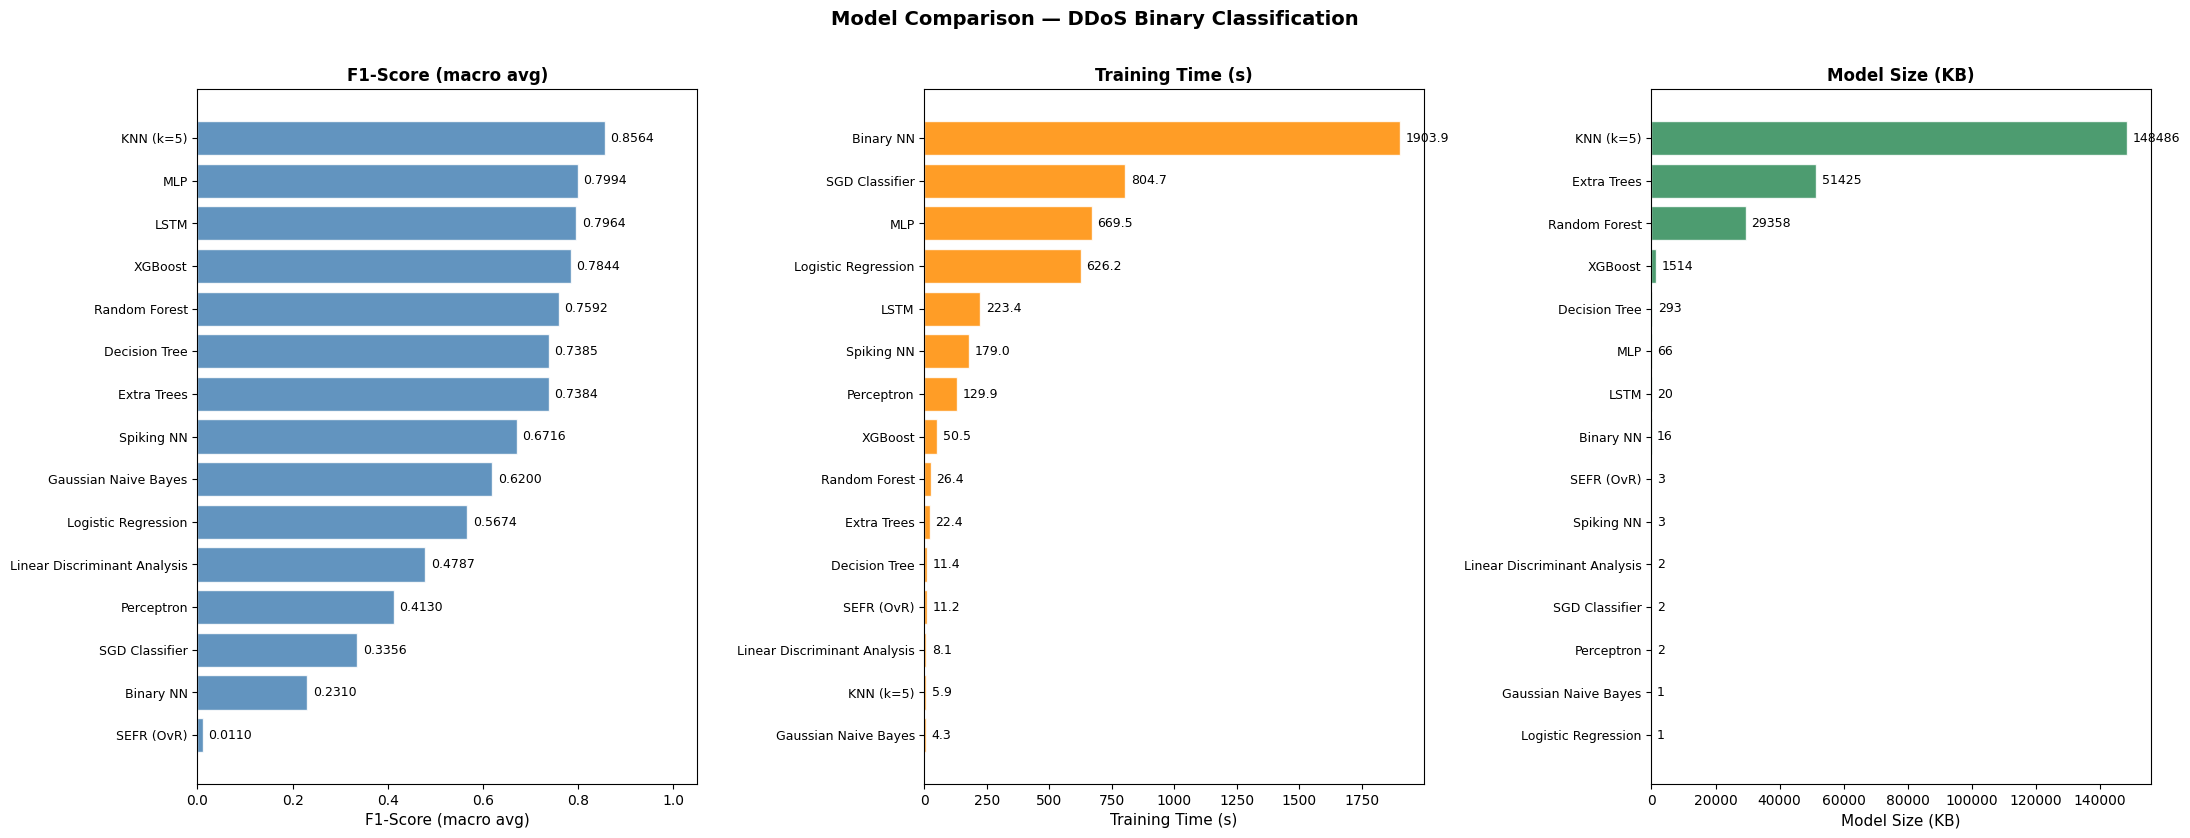

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(22, max(6, len(results) * 0.55)))

metrics = [
    ("F1-Score",       "steelblue",  "F1-Score (macro avg)",     "%.4f", (0, 1.05)),
    ("Train Time (s)", "darkorange", "Training Time (s)",         "%.1f",  None),
    ("Model Size (KB)","seagreen",   "Model Size (KB)",           "%.0f",  None),
]

for ax, (metric, color, title, fmt, xlim) in zip(axes, metrics):
    df_s = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(df_s["Model"], df_s[metric], color=color, alpha=0.85, edgecolor="white")
    ax.bar_label(bars, fmt=fmt, padding=4, fontsize=9)
    ax.set_xlabel(title, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.tick_params(axis="y", labelsize=9)
    if xlim:
        ax.set_xlim(*xlim)

plt.suptitle("Model Comparison — DDoS Binary Classification", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()